In [17]:
import numpy as np
from numpy import sqrt, zeros, ones, pi, linspace, sin, cos, tan, atan 
import matplotlib.pyplot as plt

### We wish to find the dispersions of electromagnetic modes supported by a metal-insulator interface (for which the metal has a nonlocal longitudinal permittivity). To this end, we use Eq. (11) of https://journals.aps.org/prb/pdf/10.1103/PhysRevB.88.115401 which we reiterate below: 

$\begin{align*}
1+\frac{\varepsilon_m\kappa_d}{\varepsilon_d \kappa_m} +\delta_{nl}=0\rightarrow  
1+\frac{\varepsilon_m\kappa_d}{\varepsilon_d \kappa_m} + \frac{k^2}{\kappa_{m} \kappa_{nl}}(\varepsilon_m-1),
\end{align*}$

where the local permittivity of the metal, $\varepsilon_m$, and the wavenumbers $\kappa_{m}$, $\kappa_d$, $\kappa_{nl}$ are given by the following expressions: 

$\begin{align*}
&\varepsilon_m(\omega) = 1-\frac{\omega_p^2}{\omega^2+i\omega\gamma}=1-\frac{1}{\Omega(\Omega+i\Gamma)}
\\& \kappa_m = \sqrt{k^2-\varepsilon_m(\omega/c)^2} = (\omega_p/c)\sqrt{K^2-\varepsilon_m\Omega^2}
\\& \kappa_d = \sqrt{k^2-\varepsilon_d(\omega/c)^2} = (\omega_p/c)\sqrt{K^2-\varepsilon_d\Omega^2}
\\&\kappa_{nl}=\sqrt{k^2-(\omega^2+i\gamma\omega-\omega_p^2)/\beta_F^2}=(\omega_p/c)\sqrt{K^2-(\Omega^2+i\Gamma\Omega-1)/\eta^2}
\end{align*}$

In [2]:
def return_epsilon_m(omega, gamma):
    return 1-1/(omega*(omega+1j*gamma))
def return_kappa_nl(k, omega, gamma, eta):
    return sqrt(k**2-(omega**2+1j*gamma*omega-1)/eta**2+ 0j)
def return_kappa_m(k, omega, gamma):
    return sqrt(k**2-return_epsilon_m(omega, gamma)*omega**2 + 0j)
def return_kappa_d(k, omega, epsilon_d):
    return sqrt(k**2-epsilon_d*omega**2+ 0j)

In [3]:
def equation_11(k, omega, gamma, eta, epsilon_d=1):
    epsilon_m = return_epsilon_m(omega, gamma)
    kappa_d = return_kappa_d(k, omega, epsilon_d)
    kappa_m = return_kappa_m(k, omega, gamma)
    kappa_nl = return_kappa_nl(k, omega, gamma, eta)

    kappa_d_real = kappa_d.real
    kappa_m_real = kappa_m.real
    kappa_nl_real = kappa_nl.real

    kappa_d = np.where(kappa_d_real < 0, -kappa_d, kappa_d)
    kappa_m = np.where(kappa_m_real < 0, -kappa_m, kappa_m)
    kappa_nl = np.where(kappa_nl_real < 0, -kappa_nl, kappa_nl)

    return 1 + (epsilon_m*kappa_d)/(epsilon_d*kappa_m)+(epsilon_m-1)/(kappa_m*kappa_nl)

In [67]:
eta = 5e-3
N_k_real = 1000
N_k_imag = 1000
#gamma = 0.1
gamma = 1e-3
N_omega = 250
k_v_real = np.linspace(0, 100, N_k_real)
#k_v_imag = np.linspace(0, 2, N_k_imag)
k_v_imag = np.linspace(0, 1, N_k_imag)
omega_v = np.linspace(0.5, 0.9, N_omega)
k_mat_real = np.repeat(np.reshape(k_v_real, (N_k_real, 1)), N_k_imag, axis=1)
k_mat_imag = np.repeat(np.reshape(k_v_imag, (1, N_k_imag)), N_k_real, axis=0)

In [68]:
dispersion_k_real = zeros(N_omega)
dispersion_k_imag = zeros(N_omega)
dispersion_mat = zeros((N_omega, N_k_real, N_k_imag), dtype=complex)
for (omega_idx, omega) in enumerate(omega_v):
    dispersion_relation = equation_11(k_mat_real + 1j*k_mat_imag, omega*ones((N_k_real, N_k_imag)), gamma, eta)
    row, col = np.unravel_index(np.argmin(np.abs(dispersion_relation)), (N_k_real, N_k_imag))
    dispersion_k_real[omega_idx] = k_v_real[row]
    dispersion_k_imag[omega_idx] = k_v_imag[col]
    dispersion_mat[omega_idx, :] = dispersion_relation

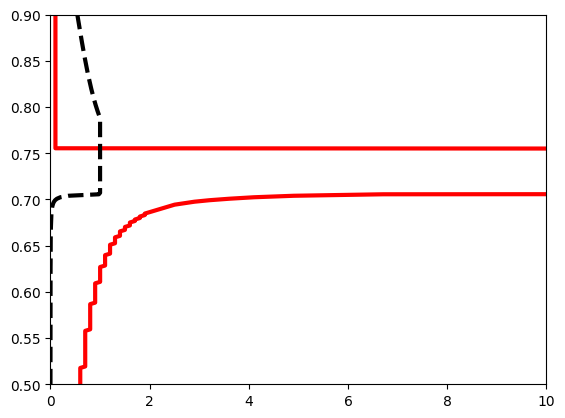

In [71]:
plt.plot(dispersion_k_real, omega_v, color="red", linewidth=3)
plt.plot(dispersion_k_imag, omega_v, linestyle="dashed", color="black", linewidth=3)
plt.ylim(0.5, 0.9)
plt.xlim(0, 10);

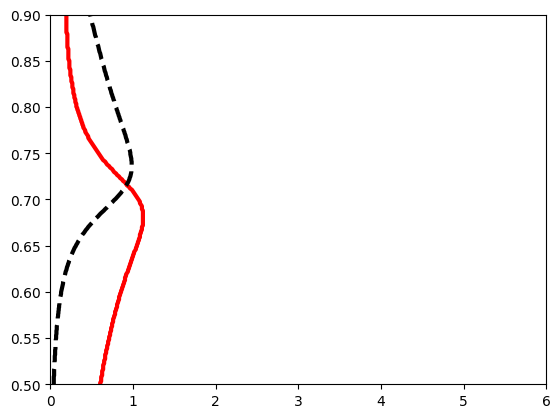

In [33]:
plt.plot(dispersion_k_real, omega_v, color="red", linewidth=3)
plt.plot(dispersion_k_imag, omega_v, linestyle="dashed", color="black", linewidth=3)
plt.ylim(0.5, 0.9)
plt.xlim(0, 6);

In [52]:
dispersion_mat_nonlocal = equation_11(k_mat, omega_mat, gamma, eta)
dispersion_mat_local = equation_11(k_mat, omega_mat, gamma, 1e-8)

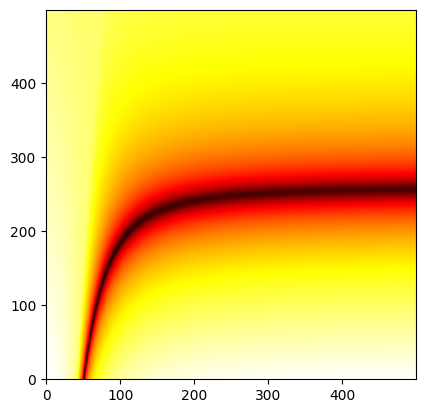

In [50]:
plt.imshow(np.log(np.abs(dispersion_mat_nonlocal)).T, cmap="hot", origin="lower")

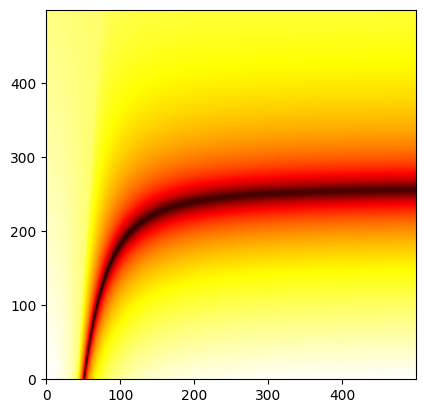

In [53]:
plt.imshow(np.log(np.abs(dispersion_mat_local)).T, cmap="hot", origin="lower")

### The code below reproduces (hopefully) figures 1 and 5 of the paper [Incoherent perfect absorption in lossy anisotropic materials](https://opg.optica.org/abstract.cfm?uri=oe-27-7-9561). Note that we define (in the notation of the linked paper) $\theta=\tan^{-1}(k_\tau/k_{n1})$, meaning $\theta$ is the angle from the  normal. For an isotropic medium, the absolute value of the p-polarized reflection coefficient will be given by the following:
$\begin{align*}
|r_p|=\Bigg|\frac{\varepsilon k_{n1}-k_{n2}}{\varepsilon k_{n1}+k_{n2}}\Bigg| = \Bigg|\frac{\varepsilon\cot(\theta)-\sqrt{\varepsilon\cot^2(\theta)+(\varepsilon-1)}}{\varepsilon\cot(\theta)+\sqrt{\varepsilon\cot^2(\theta)+(\varepsilon-1)}}\Bigg|=\Bigg|\frac{\varepsilon\cos(\theta)-\sqrt{\varepsilon-\sin^2(\theta)}}{\varepsilon\cos(\theta)+\sqrt{\varepsilon-\sin^2(\theta)}}\Bigg|
\end{align*}$,

where we used the following:

$\begin{align*}
&k_{n2}=\sqrt{\varepsilon(\omega/c)^2-k_\tau^2}=\sqrt{\varepsilon\Big[(\omega/c)^2-k_\tau^2 \Big]+(\varepsilon-1)k_\tau^2}
=k_\tau\sqrt{\varepsilon k_{n1}^2/k_\tau^2+(\varepsilon-1)}=k_\tau\sqrt{\varepsilon\cot^2(\theta)+(\varepsilon-1)}
\end{align*}$

Note that requiring the reflection coefficient to vanish immediately gives us the Brewster angle:

$\varepsilon^2-\sin^2(\theta)\varepsilon^2=\varepsilon-\sin^2(\theta)\rightarrow \varepsilon(\varepsilon-1)=\sin^2(\theta)(\varepsilon^2-1)\rightarrow \sin^2(\theta)=\varepsilon/(\varepsilon+1)$, $\cos^2(\theta)=1/(\varepsilon+1), \tan^2(\theta)=\varepsilon$

In [2]:
def r_p(epsilon, theta):
    numerator = epsilon*cos(theta)-sqrt(epsilon-sin(theta)**2)
    denominator = epsilon*cos(theta)+sqrt(epsilon-sin(theta)**2)
    return np.abs(numerator/denominator)

In [26]:
N = 100000
angles = np.linspace(0, 90, N)
r_p_v_no_loss = r_p(2, angles*pi/180)
r_p_v_with_loss = r_p(2+2j, angles*pi/180)
brewster_angle = angles[np.argmin(r_p_v_no_loss)]

### Below is Figure 1 of the Narimanov paper

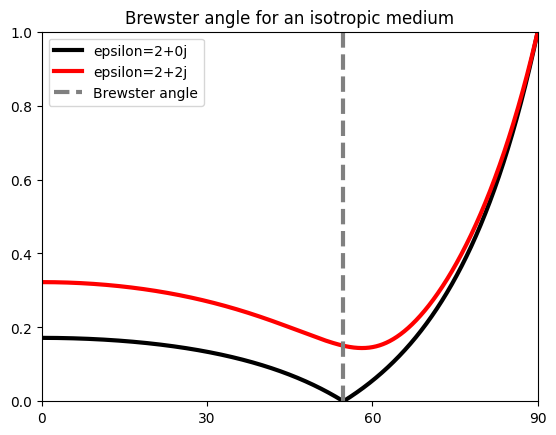

In [27]:
plt.plot(angles, r_p_v_no_loss, color="black", label="epsilon=2+0j", linewidth=3)
plt.plot(angles, r_p_v_with_loss, color="red", label="epsilon=2+2j", linewidth=3)
plt.vlines([brewster_angle], 0, 1, color="Grey", linestyle="dashed", linewidth=3, label="Brewster angle")
plt.ylim(0, 1)
plt.xlim(0, 90)
plt.yticks(linspace(0, 1, 6))
plt.xticks(linspace(0, 90, 4))
plt.legend();
plt.title("Brewster angle for an isotropic medium");

In [28]:
print("Brewster angle (in degrees): ", brewster_angle.round(3))
print("Brewster angle as predicted by formula: ", (atan(sqrt(2))*180/pi).round(3))

Brewster angle (in degrees):  54.736
Brewster angle as predicted by formula:  54.736


### Now we move on to anisotropic materials. In this case, the absolute value of the reflection coefficient is given by the following (again, in the notation of the Narimanov paper):

$\begin{align*}
|r_p| = \Bigg|\frac{k_{1n}\varepsilon_{2\tau}-k_{2n}}{k_{1n}\varepsilon_{2\tau}+k_{2n}}\Bigg|=\Bigg|\frac{\varepsilon_{2\tau}\cot(\theta)-k_{2n}/k_\tau}{\varepsilon_{2\tau}\cot(\theta)+k_{2n}/k_\tau} \Bigg|
\end{align*}$,

where $k_{2n}$ is given by the following expression:

$\begin{align*}
k_{2n}=\sqrt{\varepsilon_{2\tau}(\omega/c)^2-(\varepsilon_{2\tau}/\varepsilon_{2n})k_\tau^2}=\sqrt{\varepsilon_{2\tau}\Big[(\omega/c)^2-k_\tau^2\Big]+\varepsilon_{2\tau}\Big[1-1/\varepsilon_{2n}\Big]k_\tau^2}=k_\tau\sqrt{\varepsilon_{2\tau}\cot^2(\theta)+\varepsilon_{2\tau}(1-1/\varepsilon_{2n})}
\end{align*}$

In [29]:
def r_p_anisotropic(epsilon_tau, epsilon_n, theta):
    numerator = epsilon_tau/tan(theta)-sqrt(epsilon_tau/tan(theta)**2+epsilon_tau*(1-1/epsilon_n))
    denominator = epsilon_tau/tan(theta)+sqrt(epsilon_tau/tan(theta)**2+epsilon_tau*(1-1/epsilon_n))
    return np.abs(numerator/denominator)

### First we check that this reduces to the isotropic case for $\varepsilon_{2n}=\varepsilon_{2n}$

In [34]:
N = 1000
angles = np.linspace(0.0001, 90-0.0001, N)
r_p_v_no_loss = r_p_anisotropic(2, 2, angles*pi/180)
brewster_angle = angles[np.argmin(r_p_v_no_loss)]

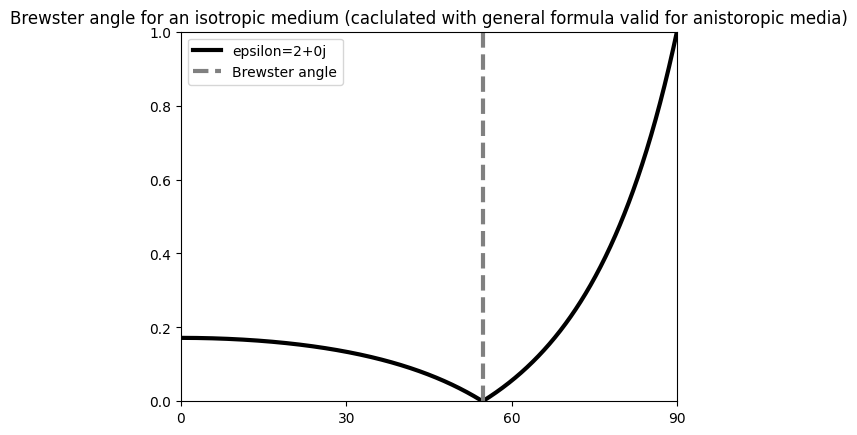

In [35]:
plt.plot(angles, r_p_v_no_loss, color="black", label="epsilon=2+0j", linewidth=3)
plt.vlines([brewster_angle], 0, 1, color="Grey", linestyle="dashed", linewidth=3, label="Brewster angle")
plt.ylim(0, 1)
plt.xlim(0, 90)
plt.legend();
plt.yticks(linspace(0, 1, 6))
plt.xticks(linspace(0, 90, 4))
plt.title("Brewster angle for an isotropic medium (caclulated with general formula valid for anistoropic media)");

### Now we check that we get a Brewster angle (zero reflection) for hBN for the two values of the permittivity given in Section 5 of the Narimanov paper: 

In [67]:
epsilon_n_1_hbn = 7.351 + 0.038j # For angular frequency of 611.7 cm^-1 
epsilon_tau_1_hbn = 6.794 + 0.0047j # For angular frequency of 611.7 cm^-1 

epsilon_n_2_hbn = 3.051 + 0.0159j # For angular frequency of 952.8 cm^-1
epsilon_tau_2_hbn = 8.084 + 0.0180j # For angular frequency of 952.8 cm^-1

In [68]:
N = 10000
angles = np.linspace(1e-4, 90-1e-4, N) # We avoid theta = 0 since we are diving by tangent in the above
r_p_v_hbn_1 = r_p_anisotropic(epsilon_tau_1_hbn, epsilon_n_1_hbn, angles*pi/180) # For angular frequency of 611.7 cm^-1 
r_p_v_hbn_2 = r_p_anisotropic(epsilon_tau_2_hbn, epsilon_n_2_hbn, angles*pi/180) # For angular frequency of 952.8 cm^-1

### Below is Figure 5 of the Narimanov paper

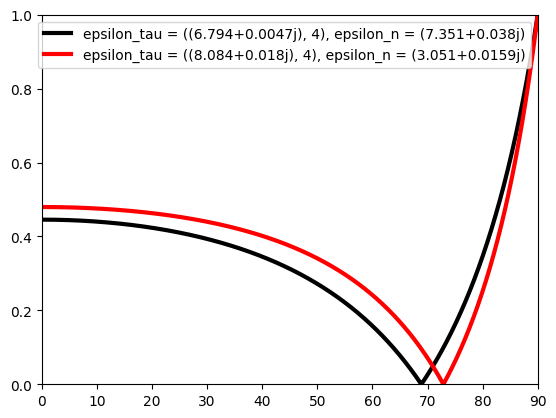

In [69]:
plt.plot(angles, r_p_v_hbn_1, color="black", label=f"epsilon_tau = {epsilon_tau_1, digits}, epsilon_n = {epsilon_n_1}", linewidth=3)
plt.plot(angles, r_p_v_hbn_2, color="red", label=f"epsilon_tau = {epsilon_tau_2, digits}, epsilon_n = {epsilon_n_2}", linewidth=3)
plt.ylim(0, 1)
plt.xlim(0, 90)
plt.legend();

In [70]:
brewster_angle_hbn_1 = angles[np.argmin(r_p_v_hbn_1)]
print("Brewster angle for omega=611.7 cm^-1 (in degrees): ", brewster_angle_hbn_1)

brewster_angle_hbn_2 = angles[np.argmin(r_p_v_hbn_2)]
print("Brewster angle for omega=952.8 cm^-1 (in degrees): ", brewster_angle_hbn_2)

Brewster angle for omega=611.7 cm^-1 (in degrees):  68.88383531353136
Brewster angle for omega=952.8 cm^-1 (in degrees):  72.88022607260726


In [71]:
for (epsilon_n, epsilon_tau) in zip((epsilon_n_1_hbn, epsilon_n_2_hbn), (epsilon_tau_1_hbn, epsilon_tau_2_hbn)):
    k_tau_sqrd = epsilon_n * (1-epsilon_tau)/(1-epsilon_n*epsilon_tau)
    k_n_1_sqrd = 1-k_tau_sqrd
    brewster_angle = atan(sqrt(k_tau_sqrd/k_n_1_sqrd))*180/pi
    print("Brewster angle: ", brewster_angle.real)

Brewster angle:  68.88577815853456
Brewster angle:  72.87839849222968


### Now we do the same calculation for Sapphire ($\text{Al}_2\text{O}_3$), again at two different frequencies for which the material properties are conducive to a real valued Brewster angle.

In [72]:
epsilon_n_1_sapphire = -1.474 + 0.146j
epsilon_tau_1_sapphire = 8.326 + 0.292j
epsilon_n_2_sapphire = 2.099 + 0.079j
epsilon_tau_2_sapphire = 15.274 + 0.491j

In [81]:
N = 100000
angles = np.linspace(1e-4, 90-1e-4, N) # We avoid theta = 0 since we are diving by tangent in the above
r_p_v_sapphire_1 = r_p_anisotropic(epsilon_tau_1_sapphire, epsilon_n_1_sapphire, angles*pi/180) # For angular frequency of 503.46 cm^-1 
r_p_v_sapphire_15 = r_p_anisotropic(epsilon_tau_1_sapphire, epsilon_tau_1_sapphire, angles*pi/180) # For angular frequency of 503.46 cm^-1 
r_p_v_sapphire_2 = r_p_anisotropic(epsilon_tau_2_sapphire, epsilon_n_2_sapphire, angles*pi/180) # For angular frequency of 520.93 cm^-1

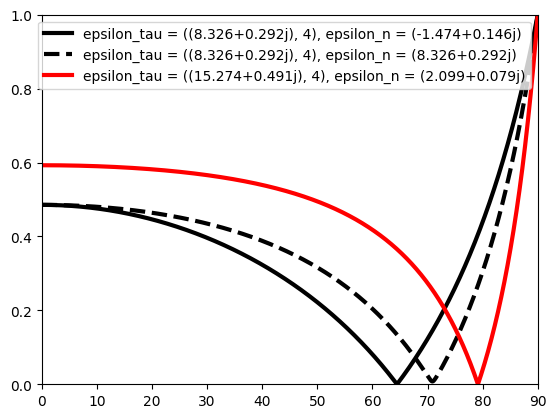

In [84]:
plt.plot(angles, r_p_v_sapphire_1, color="black", label=f"epsilon_tau = {epsilon_tau_1_sapphire, digits}, epsilon_n = {epsilon_n_1_sapphire}", linewidth=3)
plt.plot(angles, r_p_v_sapphire_15, color="black", label=f"epsilon_tau = {epsilon_tau_1_sapphire, digits}, epsilon_n = {epsilon_tau_1_sapphire}", linewidth=3, linestyle="dashed")
plt.plot(angles, r_p_v_sapphire_2, color="red", label=f"epsilon_tau = {epsilon_tau_2_sapphire, digits}, epsilon_n = {epsilon_n_2_sapphire}", linewidth=3)
plt.ylim(0, 1)
plt.xlim(0, 90)
plt.legend();

In [88]:
r_p_v_sapphire_15.min()/r_p_v_sapphire_1.min()

np.float64(647.2123347801346)

In [79]:
brewster_angle_sapphire_1 = angles[np.argmin(r_p_v_sapphire_1)]
print("Brewster angle for omega=503.46 cm^-1 (in degrees): ", brewster_angle_sapphire_1)

brewster_angle_sapphire_2 = angles[np.argmin(r_p_v_sapphire_2)]
print("Brewster angle for omega=520.93 cm^-1 (in degrees): ", brewster_angle_sapphire_2)

Brewster angle for omega=503.46 cm^-1 (in degrees):  64.465801401014
Brewster angle for omega=520.93 cm^-1 (in degrees):  79.15121562115621


In [80]:
for (epsilon_n, epsilon_tau) in zip((epsilon_n_1_sapphire, epsilon_n_2_sapphire), (epsilon_tau_1_sapphire, epsilon_tau_2_sapphire)):
    k_tau_sqrd = epsilon_n * (1-epsilon_tau)/(1-epsilon_n*epsilon_tau)
    k_n_1_sqrd = 1-k_tau_sqrd
    brewster_angle = atan(sqrt(k_tau_sqrd/k_n_1_sqrd))*180/pi
    print("Brewster angle: ", brewster_angle.real)

Brewster angle:  64.46580885079936
Brewster angle:  79.1510980679051


### We now calculate the Brewster angle in the presence of spatial nonlocality. We take the field above the nonlocal material to be given by the following polarization vectors: 

$\begin{align*}
&\Big(\sqrt{(\omega/c)^2-k_\tau^2}, k_\tau\Big) \text{ for the incident field } \\
&r_p\Big(-\sqrt{(\omega/c)^2-k_\tau^2}, k_\tau\Big) \text{ for the reflected field } \\ 
&t_p\Big(\Big(\sqrt{\varepsilon_m(\omega/c)^2-k_\tau^2}, k_\tau\Big) + \alpha\Big(k_\tau, -\sqrt{k_{nl}^2-k_\tau^2}\Big)\Big)
\end{align*}$

$(1-r_p)q_1=(q_2+\alpha k_\tau)t_p$

$(1+r_p)=\varepsilon_m t_p$

$k_\tau(1+r_p)=(k_\tau-\alpha q_{nl})t_p$

$\begin{align*}
(1-r_p)q_1\varepsilon_m q_{nl}=(1+r_p)(q_2q_{nl} +k_\tau^2(1-\varepsilon_m))
\end{align*}$

Therefore the reflection coefficient is given by the following: 

$\begin{align*}
\frac{q_2q_{nl}+k_\tau^2(1-\varepsilon_m)-q_1q_{nl}\varepsilon_m}{(\varepsilon_m-1)k_\tau^2-q_2q_{nl}-\varepsilon_mq_1q_{nl}}
\end{align*}$